In [1]:
# ============================================
# CELL 1: Install Dependencies
# ============================================
!pip install -q torch torchvision
!pip install -q wandb
!pip install -q opencv-python-headless
!pip install -q seaborn scikit-learn
!pip install -q flwr  # For future use

print("✅ All dependencies installed!")

✅ All dependencies installed!


In [2]:
# ============================================
# CELL 2: WandB Setup
# ============================================
import wandb

# Initialize WandB (will prompt for login first time)
wandb.login()

# Create a new run for data exploration
wandb.init(
    project="fl-pneumonia-detection",
    name="day2-data-exploration",
    config={
        "phase": "preprocessing",
        "dataset": "kaggle-chest-xray",
        "week": 1,
        "day": 2
    }
)

print("✅ WandB initialized!")

wandb: Currently logged in as: chiwa-vw (chiwa-vw-personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ WandB initialized!


In [7]:
# ============================================
# CELL 3: Mount Google Drive & Setup Paths (CORRECTED)
# ============================================
from google.colab import drive
drive.mount('/content/drive')

import os

# YOUR ACTUAL FOLDER STRUCTURE
PROJECT_ROOT = '/content/drive/MyDrive/FL-Pneumonia-Detection'
os.chdir(PROJECT_ROOT)

# Define paths using your existing structure
DATA_RAW = os.path.join(PROJECT_ROOT, 'data/raw')
DATA_PROCESSED = os.path.join(PROJECT_ROOT, 'data/processed')
DATA_SPLITS = os.path.join(PROJECT_ROOT, 'data/splits')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')

# FIX: The data is nested - chest_xray/chest_xray/train/...
CHEST_XRAY_DIR = os.path.join(DATA_RAW, 'chest_xray', 'chest_xray')

print(f"📁 Project root: {PROJECT_ROOT}")
print(f"📂 Raw data: {DATA_RAW}")
print(f"📂 Chest X-ray data: {CHEST_XRAY_DIR}")
print(f"\n✅ Paths configured!")

# Verify the corrected path
if os.path.exists(CHEST_XRAY_DIR):
    print(f"✅ Found chest_xray folder!")
    contents = os.listdir(CHEST_XRAY_DIR)
    print(f"   Contents: {contents}")

    # Check if train/test/val exist
    for folder in ['train', 'test', 'val']:
        folder_path = os.path.join(CHEST_XRAY_DIR, folder)
        if os.path.exists(folder_path):
            print(f"   ✅ {folder}/ exists")
        else:
            print(f"   ❌ {folder}/ NOT FOUND")
else:
    print(f"⚠️  chest_xray folder not found at {CHEST_XRAY_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Project root: /content/drive/MyDrive/FL-Pneumonia-Detection
📂 Raw data: /content/drive/MyDrive/FL-Pneumonia-Detection/data/raw
📂 Chest X-ray data: /content/drive/MyDrive/FL-Pneumonia-Detection/data/raw/chest_xray/chest_xray

✅ Paths configured!
✅ Found chest_xray folder!
   Contents: ['.DS_Store', 'test', 'train', 'val']
   ✅ train/ exists
   ✅ test/ exists
   ✅ val/ exists


In [9]:
# ============================================
# CELL 4: Explore Dataset Structure
# ============================================
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image

# Assuming Kaggle structure: chest_xray/train, chest_xray/test, chest_xray/val
# Each with subfolders: NORMAL, PNEUMONIA

def count_images(base_path):
    """Count images in each category"""
    stats = {}
    for split in ['train', 'test', 'val']:
        split_path = os.path.join(base_path, split)
        if not os.path.exists(split_path):
            continue
        stats[split] = {}
        for category in ['NORMAL', 'PNEUMONIA']:
            cat_path = os.path.join(split_path, category)
            if os.path.exists(cat_path):
                count = len([f for f in os.listdir(cat_path) if f.endswith(('.jpeg', '.jpg', '.png'))])
                stats[split][category] = count
    return stats

# Count images
dataset_stats = count_images(CHEST_XRAY_DIR)
print("📊 Dataset Statistics:")
print("-" * 50)

total_images = 0
for split, categories in dataset_stats.items():
    print(f"\n{split.upper()}:")
    for cat, count in categories.items():
        print(f"  {cat}: {count} images")
        total_images += count

print(f"{'='*50}")
print(f"TOTAL IMAGES: {total_images}")
print(f"{'='*50}")

# Log to WandB
wandb.log({"total_images": total_images})
for split, categories in dataset_stats.items():
    for cat, count in categories.items():
        wandb.log({f"{split}_{cat}": count})

📊 Dataset Statistics:
--------------------------------------------------

TRAIN:
  NORMAL: 1341 images
  PNEUMONIA: 3875 images

TEST:
  NORMAL: 234 images
  PNEUMONIA: 390 images

VAL:
  NORMAL: 8 images
  PNEUMONIA: 8 images
TOTAL IMAGES: 5856


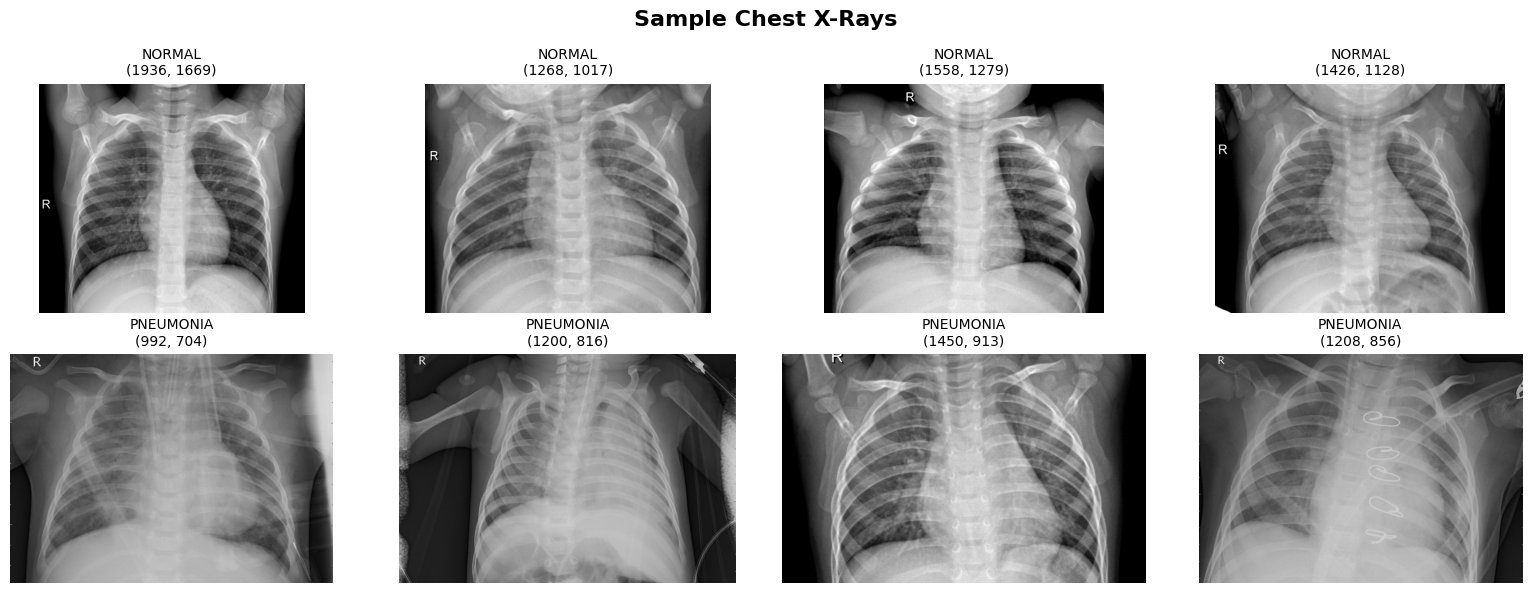

✅ Sample visualization complete!


In [11]:
# ============================================
# CELL 5: Visualize Sample Images
# ============================================
def show_samples(data_dir, n_samples=8):
    """Display sample images from each class"""
    fig, axes = plt.subplots(2, n_samples//2, figsize=(16, 6))
    fig.suptitle("Sample Chest X-Rays", fontsize=16, fontweight='bold')

    # Get sample images
    normal_dir = os.path.join(data_dir, 'train/NORMAL')
    pneumonia_dir = os.path.join(data_dir, 'train/PNEUMONIA')

    normal_images = [f for f in os.listdir(normal_dir) if f.endswith(('.jpeg', '.jpg'))][:n_samples//2]
    pneumonia_images = [f for f in os.listdir(pneumonia_dir) if f.endswith(('.jpeg', '.jpg'))][:n_samples//2]

    # Display normal images
    for i, img_name in enumerate(normal_images):
        img_path = os.path.join(normal_dir, img_name)
        img = Image.open(img_path)
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(f"NORMAL\n{img.size}", fontsize=10)
        axes[0, i].axis('off')

    # Display pneumonia images
    for i, img_name in enumerate(pneumonia_images):
        img_path = os.path.join(pneumonia_dir, img_name)
        img = Image.open(img_path)
        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].set_title(f"PNEUMONIA\n{img.size}", fontsize=10)
        axes[1, i].axis('off')

    plt.tight_layout()

    # Save to WandB
    wandb.log({"sample_images": wandb.Image(fig)})
    plt.show()

show_samples(CHEST_XRAY_DIR)
print("✅ Sample visualization complete!")


📐 Image Properties Summary:
--------------------------------------------------
mean_width: 1402.50
mean_height: 1068.79
median_width: 1400.00
median_height: 1051.50
mean_aspect_ratio: 1.37


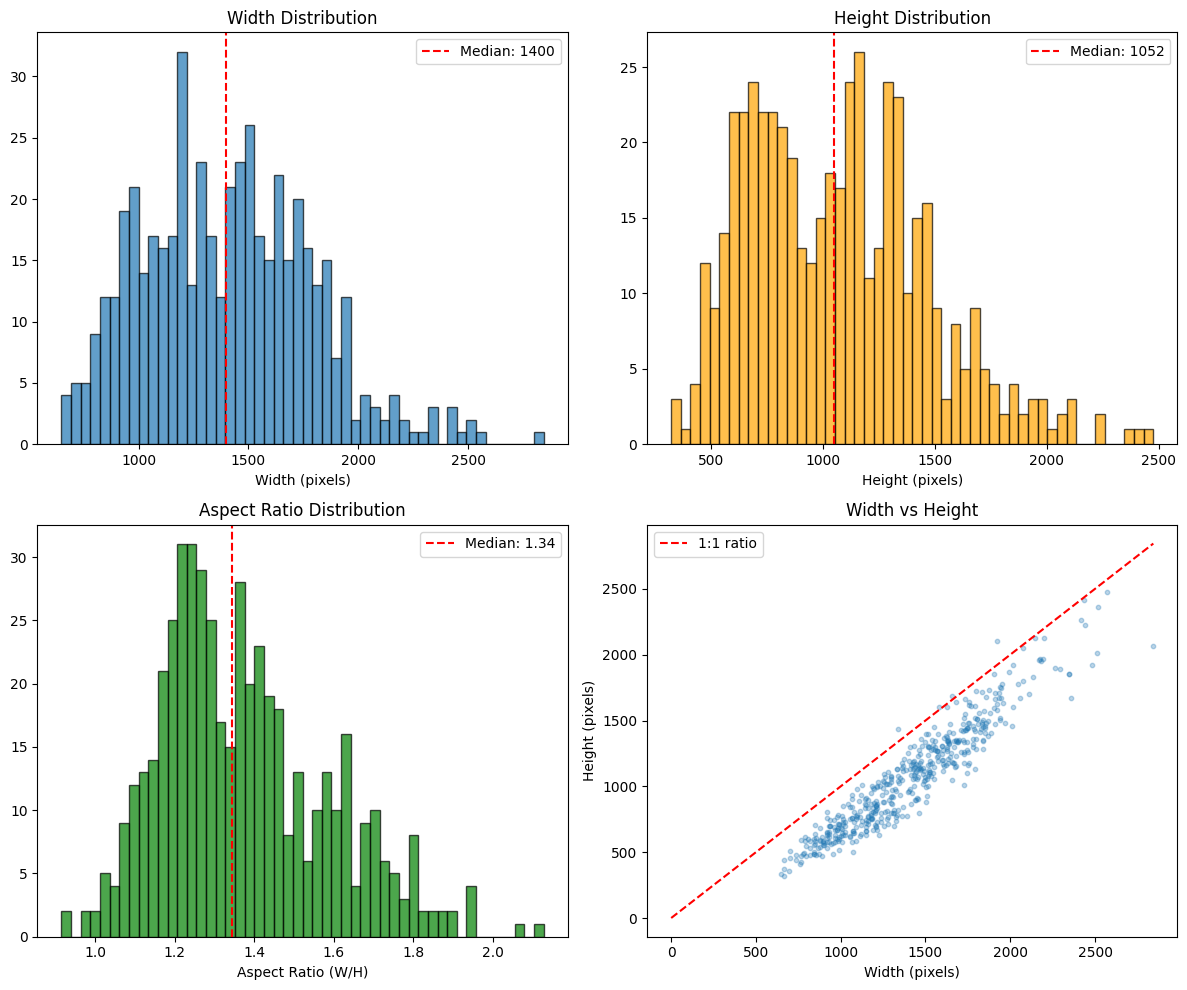


✅ Image analysis complete!


In [13]:
# ============================================
# CELL 6: Analyze Image Dimensions & Properties
# ============================================
from collections import defaultdict
import cv2

def analyze_image_properties(data_dir, sample_size=500):
    """Analyze dimensions and properties of images"""
    widths, heights, aspect_ratios = [], [], []

    # Sample from training set
    for category in ['NORMAL', 'PNEUMONIA']:
        cat_dir = os.path.join(data_dir, 'train', category)
        images = [f for f in os.listdir(cat_dir) if f.endswith(('.jpeg', '.jpg'))][:sample_size//2]

        for img_name in images:
            img_path = os.path.join(cat_dir, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                h, w = img.shape[:2]
                widths.append(w)
                heights.append(h)
                aspect_ratios.append(w/h)

    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Width distribution
    axes[0, 0].hist(widths, bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Width Distribution')
    axes[0, 0].set_xlabel('Width (pixels)')
    axes[0, 0].axvline(np.median(widths), color='red', linestyle='--', label=f'Median: {np.median(widths):.0f}')
    axes[0, 0].legend()

    # Height distribution
    axes[0, 1].hist(heights, bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[0, 1].set_title('Height Distribution')
    axes[0, 1].set_xlabel('Height (pixels)')
    axes[0, 1].axvline(np.median(heights), color='red', linestyle='--', label=f'Median: {np.median(heights):.0f}')
    axes[0, 1].legend()

    # Aspect ratio
    axes[1, 0].hist(aspect_ratios, bins=50, edgecolor='black', alpha=0.7, color='green')
    axes[1, 0].set_title('Aspect Ratio Distribution')
    axes[1, 0].set_xlabel('Aspect Ratio (W/H)')
    axes[1, 0].axvline(np.median(aspect_ratios), color='red', linestyle='--', label=f'Median: {np.median(aspect_ratios):.2f}')
    axes[1, 0].legend()

    # Scatter: width vs height
    axes[1, 1].scatter(widths, heights, alpha=0.3, s=10)
    axes[1, 1].set_title('Width vs Height')
    axes[1, 1].set_xlabel('Width (pixels)')
    axes[1, 1].set_ylabel('Height (pixels)')
    axes[1, 1].plot([0, max(widths)], [0, max(widths)], 'r--', label='1:1 ratio')
    axes[1, 1].legend()

    plt.tight_layout()

    # Log statistics
    stats = {
        "mean_width": np.mean(widths),
        "mean_height": np.mean(heights),
        "median_width": np.median(widths),
        "median_height": np.median(heights),
        "mean_aspect_ratio": np.mean(aspect_ratios)
    }

    wandb.log(stats)
    wandb.log({"image_properties": wandb.Image(fig)})

    print("\n📐 Image Properties Summary:")
    print("-" * 50)
    for key, value in stats.items():
        print(f"{key}: {value:.2f}")

    plt.show()
    return stats

image_stats = analyze_image_properties(CHEST_XRAY_DIR)
print("\n✅ Image analysis complete!")

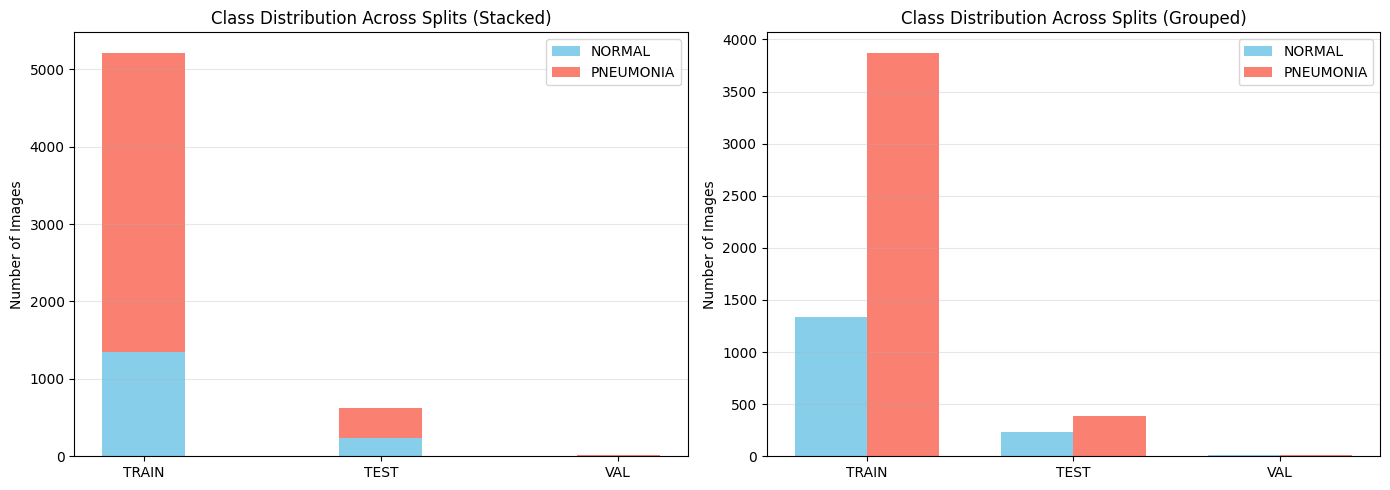


⚖️ Class Balance:
Total NORMAL: 1583
Total PNEUMONIA: 4273
Imbalance Ratio: 2.70:1

✅ Class balance analysis complete!


In [14]:
# ============================================
# CELL 7: Class Balance Visualization
# ============================================
def plot_class_distribution(dataset_stats):
    """Visualize class balance across splits"""
    splits = list(dataset_stats.keys())
    normal_counts = [dataset_stats[s].get('NORMAL', 0) for s in splits]
    pneumonia_counts = [dataset_stats[s].get('PNEUMONIA', 0) for s in splits]

    x = np.arange(len(splits))
    width = 0.35

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Stacked bar chart
    ax1.bar(x, normal_counts, width, label='NORMAL', color='skyblue')
    ax1.bar(x, pneumonia_counts, width, bottom=normal_counts, label='PNEUMONIA', color='salmon')
    ax1.set_ylabel('Number of Images')
    ax1.set_title('Class Distribution Across Splits (Stacked)')
    ax1.set_xticks(x)
    ax1.set_xticklabels([s.upper() for s in splits])
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)

    # Grouped bar chart
    ax2.bar(x - width/2, normal_counts, width, label='NORMAL', color='skyblue')
    ax2.bar(x + width/2, pneumonia_counts, width, label='PNEUMONIA', color='salmon')
    ax2.set_ylabel('Number of Images')
    ax2.set_title('Class Distribution Across Splits (Grouped)')
    ax2.set_xticks(x)
    ax2.set_xticklabels([s.upper() for s in splits])
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    wandb.log({"class_distribution": wandb.Image(fig)})
    plt.show()

    # Calculate and log imbalance ratio
    total_normal = sum(normal_counts)
    total_pneumonia = sum(pneumonia_counts)
    imbalance_ratio = total_pneumonia / total_normal

    print(f"\n⚖️ Class Balance:")
    print(f"Total NORMAL: {total_normal}")
    print(f"Total PNEUMONIA: {total_pneumonia}")
    print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1")

    wandb.log({
        "total_normal": total_normal,
        "total_pneumonia": total_pneumonia,
        "imbalance_ratio": imbalance_ratio
    })

plot_class_distribution(dataset_stats)
print("\n✅ Class balance analysis complete!")

In [16]:
# ============================================
# CELL 8: Save Summary Report
# ============================================
import json
from datetime import datetime

summary = {
    "date": datetime.now().strftime("%Y-%m-%d"),
    "week": 1,
    "day": 2,
    "milestone": "Data Exploration Complete",
    "dataset_stats": dataset_stats,
    "image_properties": image_stats,
    "total_images": sum(sum(cats.values()) for cats in dataset_stats.values()),
    "next_steps": [
        "Day 3: Create preprocessing pipeline with augmentation",
        "Day 4: Implement data partitioning (IID and non-IID)",
        "Day 5: Start centralized baseline model training"
    ]
}

# Save to Google Drive
summary_path = os.path.join(RESULTS_DIR, "day2_summary.json")
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

# Log summary to WandB
wandb.log({"day2_summary": wandb.Table(
    columns=["Metric", "Value"],
    data=[
        ["Total Images", str(summary["total_images"])], # Convert to string
        ["Mean Width", f"{image_stats['mean_width']:.0f}px"],
        ["Mean Height", f"{image_stats['mean_height']:.0f}px"],
        ["Status", "✅ Complete"]
    ]
)})

In [17]:
# Close WandB run
wandb.finish()

imbalance_ratio,▁
mean_aspect_ratio,▁
mean_height,▁
mean_width,▁
median_height,▁
median_width,▁
test_NORMAL,▁
test_PNEUMONIA,▁
total_images,▁
total_normal,▁
+5,...
